# **EDA and feature engieneering**

Importing eveything needed

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

In [ ]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
df = pd.read_csv("fake reviews dataset.csv")
df

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...
...,...,...,...,...
40427,Clothing_Shoes_and_Jewelry_5,4.0,OR,I had read some reviews saying that this bra r...
40428,Clothing_Shoes_and_Jewelry_5,5.0,CG,I wasn't sure exactly what it would be. It is ...
40429,Clothing_Shoes_and_Jewelry_5,2.0,OR,"You can wear the hood by itself, wear it with ..."
40430,Clothing_Shoes_and_Jewelry_5,1.0,CG,I liked nothing about this dress. The only rea...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB


There are 4 colums here, 1 of them is target ('label')

In [ ]:
df.isna().sum()

,0
category,0
rating,0
label,0
text_,0


In [ ]:
df.duplicated().sum()

np.int64(12)

- No `null` values
- `12` duplicate entries are there

In [ ]:
cat_col = []
num_col = []
target_col = 'label'

for col in df.columns:
    print(f"{col}: type - {df[col].dtype}")
    if col == target_col:
        continue

    if df[col].dtype == 'object':
        cat_col.append(col)
    else:
        num_col.append(col)

print(f"There are {len(num_col)} numerical column(s): {num_col}")
print(f"There are {len(cat_col)} non-numerical column(s): {cat_col}")

category: type - object
rating: type - float64
label: type - object
text_: type - object
There are 1 numerical column(s): ['rating']
There are 2 non-numerical column(s): ['category', 'text_']


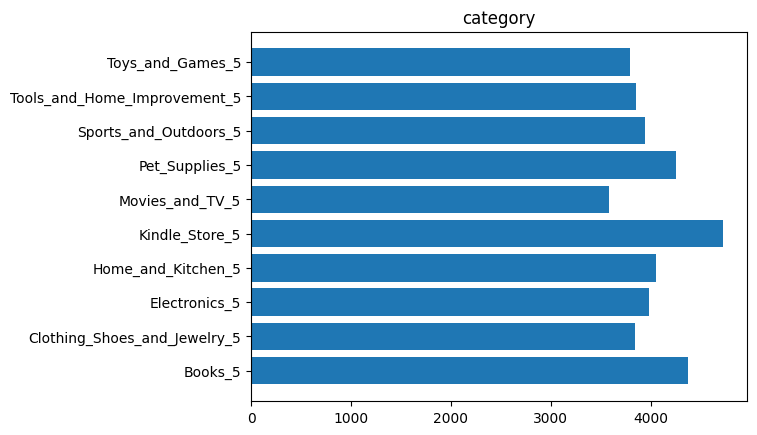

---------

category
Toys_and_Games_5                3794
Tools_and_Home_Improvement_5    3858
Sports_and_Outdoors_5           3946
Pet_Supplies_5                  4254
Movies_and_TV_5                 3588
Kindle_Store_5                  4730
Home_and_Kitchen_5              4056
Electronics_5                   3988
Clothing_Shoes_and_Jewelry_5    3848
Books_5                         4370
Name: count, dtype: int64
---------



In [ ]:
for col in cat_col:
    if col == 'text_':
        continue

    plt.barh(df[col].value_counts().sort_index().index, df[col].value_counts().sort_index().values)
    plt.title(col)
    plt.show()
    print("---------\n")
    print(df[col].value_counts().sort_index(ascending=False))
    print("---------\n")

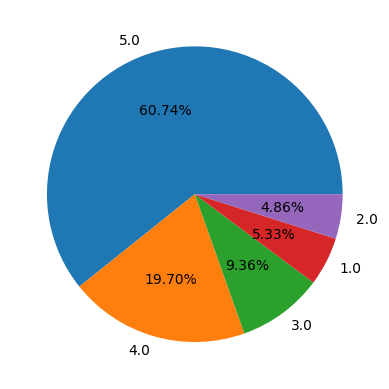

-----------
rating
5.0    24559
4.0     7965
3.0     3786
1.0     2155
2.0     1967
Name: count, dtype: int64


In [ ]:
for col in num_col:
    plt.pie(df[col].value_counts().values, labels=df[col].value_counts().index, autopct="%1.2f%%")
    plt.show()
    print("-----------")
    print(df[col].value_counts())

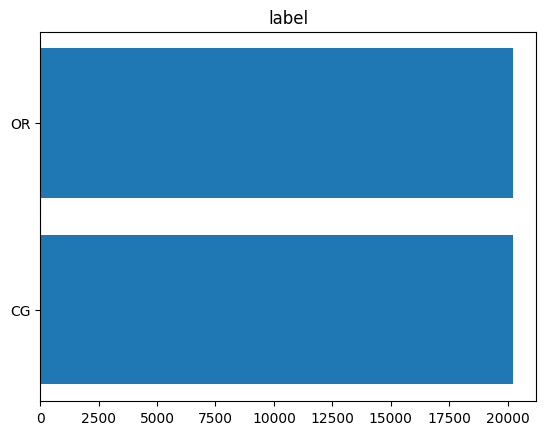

---------

label
OR    20216
CG    20216
Name: count, dtype: int64
---------



In [ ]:
plt.barh(df[target_col].value_counts().sort_index().index, df[target_col].value_counts().sort_index().values)
plt.title(target_col)
plt.show()
print("---------\n")
print(df[target_col].value_counts().sort_index(ascending=False))
print("---------\n")

In [ ]:
review_list = df['text_'].tolist()
review_list

['Love this!  Well made, sturdy, and very comfortable.  I love it!Very pretty',
 "love it, a great upgrade from the original.  I've had mine for a couple of years",
 'This pillow saved my back. I love the look and feel of this pillow.',
 'Missing information on how to use it, but it is a great product for the price!  I',
 'Very nice set. Good quality. We have had the set for two months now and have not been',
 'I WANTED DIFFERENT FLAVORS BUT THEY ARE NOT.',
 'They are the perfect touch for me and the only thing I wish they had a little more space.',
 'These done fit well and look great.  I love the smoothness of the edges and the extra',
 "Great big numbers & easy to read, the only thing I didn't like is the size of the",
 'My son loves this comforter and it is very well made.  We also have a baby',
 "As advertised. 5th one I've had. The only problem is that it's not really a",
 'Very handy for one of my kids and the tools are included in the package. I have one in',
 'Did someone say,

In [ ]:
max_len = max([len(x.strip()) for x in review_list])
max_len

2827

In [ ]:
df['review_len'] = [len(x.strip()) for x in review_list]
df

,category,rating,label,text_,review_len
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor...",75
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I...",80
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...,67
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i...",81
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...,85
...,...,...,...,...,...
40427,Clothing_Shoes_and_Jewelry_5,4.0,OR,I had read some reviews saying that this bra r...,1694
40428,Clothing_Shoes_and_Jewelry_5,5.0,CG,I wasn't sure exactly what it would be. It is ...,1304
40429,Clothing_Shoes_and_Jewelry_5,2.0,OR,"You can wear the hood by itself, wear it with ...",1987
40430,Clothing_Shoes_and_Jewelry_5,1.0,CG,I liked nothing about this dress. The only rea...,1300


In [ ]:
word_counts = []

for review in review_list:
    word_counts.append(len([x.strip() for x in review.split(" ") if x.strip() != '']))

max_words = max(word_counts)
print(max_words)

351


In [ ]:
df['word_count'] = word_counts
df

,category,rating,label,text_,review_len,word_count
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor...",75,12
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I...",80,16
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...,67,14
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i...",81,17
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...,85,18
...,...,...,...,...,...,...
40427,Clothing_Shoes_and_Jewelry_5,4.0,OR,I had read some reviews saying that this bra r...,1694,327
40428,Clothing_Shoes_and_Jewelry_5,5.0,CG,I wasn't sure exactly what it would be. It is ...,1304,269
40429,Clothing_Shoes_and_Jewelry_5,2.0,OR,"You can wear the hood by itself, wear it with ...",1987,333
40430,Clothing_Shoes_and_Jewelry_5,1.0,CG,I liked nothing about this dress. The only rea...,1300,278


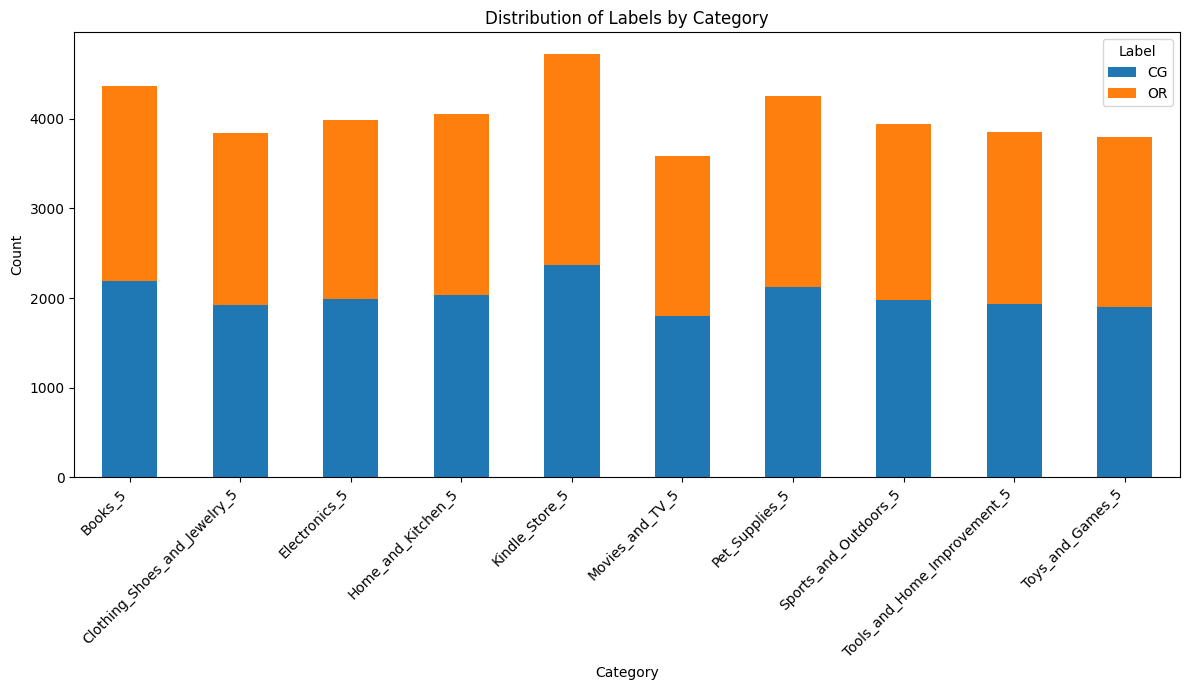

In [ ]:
crosstab_df = pd.crosstab(df['category'], df['label'])

crosstab_df.plot(kind='bar', stacked=True, figsize=(12, 7))
plt.title('Distribution of Labels by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Label')
plt.tight_layout()
plt.show()

Every category has similar almost balanced number of classes, so it won't play a singnificant role 

In [ ]:
word_count_stats = df.groupby('label')['word_count'].agg(['mean', 'median', 'min', 'max', 'std'])
print(word_count_stats)

            mean  median  min  max        std
label                                        
CG     60.965473    35.0    1  317  61.475185
OR     73.069648    42.0    5  351  75.118785


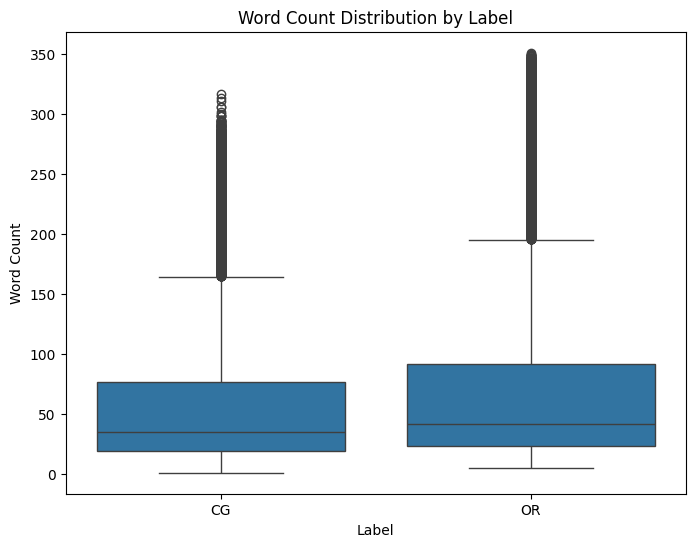

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='label', y='word_count', data=df)
plt.title('Word Count Distribution by Label')
plt.xlabel('Label')
plt.ylabel('Word Count')
plt.show()

<Axes: >

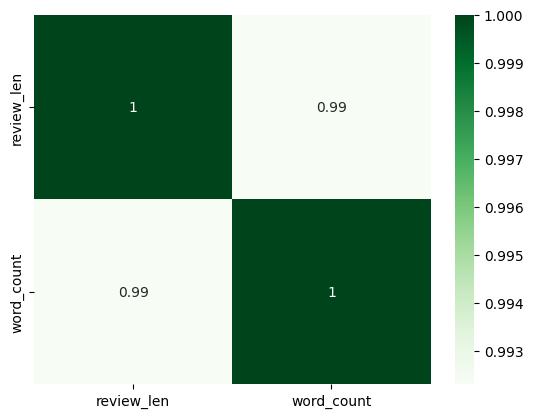

In [ ]:
sns.heatmap(df[['review_len', 'word_count']].corr(), annot=True, cmap='Greens')

In [ ]:
avg_word_len = []

for review in review_list:
    word_list = [x.strip() for x in review.split(" ") if x.strip() != '']
    total_len = 0
    for word in word_list:
        total_len += len(word)

    avg_word_len.append(total_len/len(word_list))

print(avg_word_len)

[5.166666666666667, 4.0, 3.857142857142857, 3.764705882352941, 3.7777777777777777, 4.625, 3.736842105263158, 4.0, 3.5555555555555554, 3.625, 4.066666666666666, 3.5789473684210527, 4.153846153846154, 4.294117647058823, 3.8823529411764706, 4.555555555555555, 5.4, 4.117647058823529, 4.142857142857143, 4.666666666666667, 3.6875, 4.769230769230769, 3.857142857142857, 4.285714285714286, 4.5625, 3.4705882352941178, 3.473684210526316, 4.3125, 3.526315789473684, 4.5, 3.857142857142857, 3.35, 3.588235294117647, 4.076923076923077, 4.0625, 3.6315789473684212, 3.6470588235294117, 4.0, 3.6842105263157894, 5.266666666666667, 3.9375, 3.4545454545454546, 4.5, 3.6470588235294117, 4.666666666666667, 5.071428571428571, 4.117647058823529, 3.5789473684210527, 3.789473684210526, 4.222222222222222, 3.5555555555555554, 3.526315789473684, 4.6875, 3.4444444444444446, 4.3125, 4.6, 4.0, 4.2, 4.5, 3.6, 4.6, 4.2, 6.428571428571429, 3.9, 4.6, 3.9, 5.5, 3.7, 5.3, 4.8, 3.4, 4.0, 4.444444444444445, 5.5, 4.0, 4.2, 5.0, 5

In [ ]:
df['avg_word_len'] = np.array(avg_word_len)
df

,category,rating,label,text_,review_len,word_count,avg_word_len
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor...",75,12,5.166667
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I...",80,16,4.000000
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...,67,14,3.857143
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i...",81,17,3.764706
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...,85,18,3.777778
...,...,...,...,...,...,...,...
40427,Clothing_Shoes_and_Jewelry_5,4.0,OR,I had read some reviews saying that this bra r...,1694,327,4.122324
40428,Clothing_Shoes_and_Jewelry_5,5.0,CG,I wasn't sure exactly what it would be. It is ...,1304,269,3.773234
40429,Clothing_Shoes_and_Jewelry_5,2.0,OR,"You can wear the hood by itself, wear it with ...",1987,333,4.924925
40430,Clothing_Shoes_and_Jewelry_5,1.0,CG,I liked nothing about this dress. The only rea...,1300,278,3.658273


In [ ]:
df['word_to_len_ratio'] = df['review_len']/df['word_count']
df

,category,rating,label,text_,review_len,word_count,avg_word_len,word_to_len_ratio
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor...",75,12,5.166667,6.250000
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I...",80,16,4.000000,5.000000
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...,67,14,3.857143,4.785714
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i...",81,17,3.764706,4.764706
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...,85,18,3.777778,4.722222
...,...,...,...,...,...,...,...,...
40427,Clothing_Shoes_and_Jewelry_5,4.0,OR,I had read some reviews saying that this bra r...,1694,327,4.122324,5.180428
40428,Clothing_Shoes_and_Jewelry_5,5.0,CG,I wasn't sure exactly what it would be. It is ...,1304,269,3.773234,4.847584
40429,Clothing_Shoes_and_Jewelry_5,2.0,OR,"You can wear the hood by itself, wear it with ...",1987,333,4.924925,5.966967
40430,Clothing_Shoes_and_Jewelry_5,1.0,CG,I liked nothing about this dress. The only rea...,1300,278,3.658273,4.676259


<Axes: >

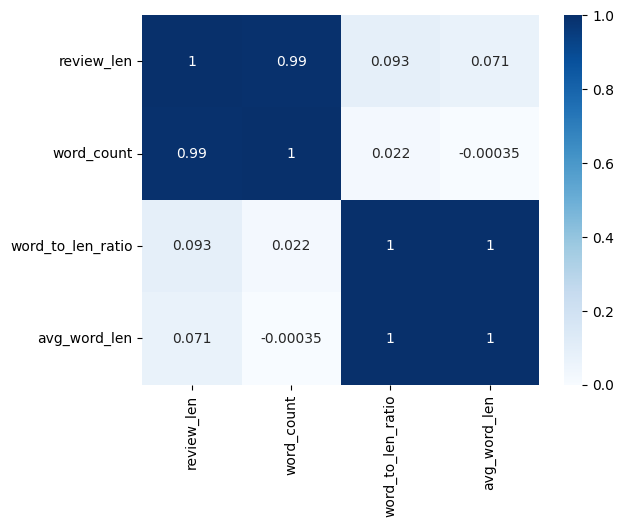

In [ ]:
sns.heatmap(df[['review_len', 'word_count', 'word_to_len_ratio', 'avg_word_len']].corr(), annot=True, cmap='Blues')

In [ ]:
num_df = df[['review_len', 'word_count', 'word_to_len_ratio', 'avg_word_len']]
num_df

,review_len,word_count,word_to_len_ratio,avg_word_len
0,75,12,6.250000,5.166667
1,80,16,5.000000,4.000000
2,67,14,4.785714,3.857143
3,81,17,4.764706,3.764706
4,85,18,4.722222,3.777778
...,...,...,...,...
40427,1694,327,5.180428,4.122324
40428,1304,269,4.847584,3.773234
40429,1987,333,5.966967,4.924925
40430,1300,278,4.676259,3.658273


In [ ]:
scaler = StandardScaler()
pca = PCA(n_components=2)

In [ ]:
pca_df_num = pca.fit_transform(num_df)
pca_df_num

array([[-2.81647581e+02, -3.94622968e+00],
       [-2.76003802e+02, -8.07810006e-01],
       [-2.89150785e+02, -3.93038371e-01],
       ...,
       [ 1.65684465e+03, -3.59372221e+01],
       [ 9.71300323e+02,  3.48763048e+01],
       [ 1.44477162e+03,  2.15376383e+01]])

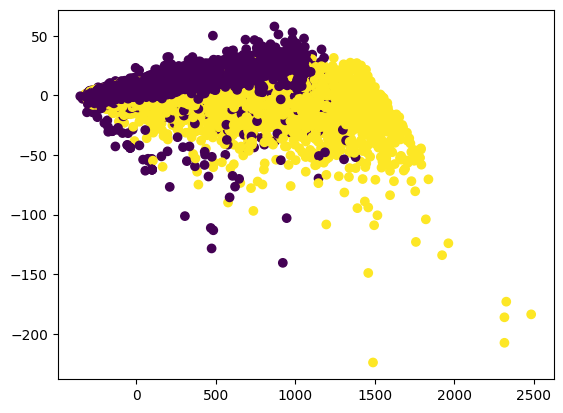

In [ ]:
plt.scatter(pca_df_num[:, 0], pca_df_num[:, 1], c=df['label'].astype('category').cat.codes)

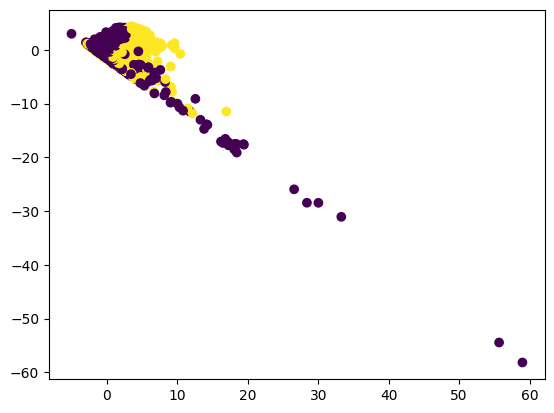

In [ ]:
pca_df_num = pca.fit_transform(scaler.fit_transform(num_df))
pca_df_num
plt.scatter(pca_df_num[:, 0], pca_df_num[:, 1], c=df['label'].astype('category').cat.codes)

In [ ]:
class TextPreprocessor:

    def __init__(self):
        # load once
        self.nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
        self.stop_words = set(stopwords.words("english"))

    def process(self, corpus):

        # tokenize
        words = word_tokenize(corpus)

        # remove stopwords
        words = [w.lower() for w in words if w.lower() not in self.stop_words]

        # lemmatize
        doc = self.nlp(" ".join(words))

        return [token.lemma_ for token in doc]

In [ ]:
pre = TextPreprocessor()

processed = []

for line, i in zip(review_list, range(len(review_list))):
    p = pre.process(line)
    p = [token for token in p if token != "."]
    processed.append(" ".join(p))
    if i%1000 == 0:
        print(f"{i} rows done: {((i/len(review_list)) * 100):.2f}% done")

0 rows done: 0.00% done
1000 rows done: 2.47% done
2000 rows done: 4.95% done
3000 rows done: 7.42% done
4000 rows done: 9.89% done
5000 rows done: 12.37% done
6000 rows done: 14.84% done
7000 rows done: 17.31% done
8000 rows done: 19.79% done
9000 rows done: 22.26% done
10000 rows done: 24.73% done
11000 rows done: 27.21% done
12000 rows done: 29.68% done
13000 rows done: 32.15% done
14000 rows done: 34.63% done
15000 rows done: 37.10% done
16000 rows done: 39.57% done
17000 rows done: 42.05% done
18000 rows done: 44.52% done
19000 rows done: 46.99% done
20000 rows done: 49.47% done
21000 rows done: 51.94% done
22000 rows done: 54.41% done
23000 rows done: 56.89% done
24000 rows done: 59.36% done
25000 rows done: 61.83% done
26000 rows done: 64.31% done
27000 rows done: 66.78% done
28000 rows done: 69.25% done
29000 rows done: 71.73% done
30000 rows done: 74.20% done
31000 rows done: 76.67% done
32000 rows done: 79.15% done
33000 rows done: 81.62% done
34000 rows done: 84.09% done
350

In [ ]:
df['processed'] = processed
df

,category,rating,label,text_,review_len,word_count,avg_word_len,word_to_len_ratio,processed
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor...",75,12,5.166667,6.250000,"love ! well make , sturdy , comfortable love !..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I...",80,16,4.000000,5.000000,"love , great upgrade original ' ve mine couple..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...,67,14,3.857143,4.785714,pillow save back love look feel pillow
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i...",81,17,3.764706,4.764706,"miss information use , great product price !"
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...,85,18,3.777778,4.722222,nice set good quality set two month
...,...,...,...,...,...,...,...,...,...
40427,Clothing_Shoes_and_Jewelry_5,4.0,OR,I had read some reviews saying that this bra r...,1694,327,4.122324,5.180428,read review say bra run small order two band c...
40428,Clothing_Shoes_and_Jewelry_5,5.0,CG,I wasn't sure exactly what it would be. It is ...,1304,269,3.773234,4.847584,not sure exactly would little large small size...
40429,Clothing_Shoes_and_Jewelry_5,2.0,OR,"You can wear the hood by itself, wear it with ...",1987,333,4.924925,5.966967,"wear hood , wear hood , wear jacket without ho..."
40430,Clothing_Shoes_and_Jewelry_5,1.0,CG,I liked nothing about this dress. The only rea...,1300,278,3.658273,4.676259,like nothing dress reason give 4 star order si...


In [ ]:
tf = TfidfVectorizer(max_features=500, ngram_range=(1, 3))
tf_reviews = tf.fit_transform(processed).toarray()

In [ ]:
tf_reviews

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.06928773, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.05179048, 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [ ]:
tf_reviews = pd.DataFrame(tf_reviews, columns=tf.get_feature_names_out())
tf_reviews

,10,able,absolutely,absolutely love,act,act good,action,actually,add,addition,...,would definitely,would definitely recommend,would like,would recommend,would recommend anyone,write,year,year old,yet,young
0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0
1,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.377647,0.0,0.0,0.0
2,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0
3,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0
4,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40427,0.000000,0.164208,0.0,0.0,0.0,0.0,0.0,0.089769,0.091075,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0
40428,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.090563,...,0.000000,0.0,0.0,0.133649,0.086622,0.0,0.000000,0.0,0.0,0.0
40429,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0
40430,0.069288,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.072126,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0


In [ ]:
tf.get_feature_names_out()

array(['10', 'able', 'absolutely', 'absolutely love', 'act', 'act good',
       'action', 'actually', 'add', 'addition', 'ago', 'almost',
       'already', 'also', 'also like', 'also love', 'although', 'always',
       'amazing', 'amazon', 'another', 'anyone', 'anything', 'area',
       'around', 'arrive', 'author', 'away', 'awesome', 'back', 'bad',
       'bag', 'base', 'battery', 'be', 'beautiful', 'become', 'bed',
       'begin', 'big', 'bike', 'bit', 'black', 'blade', 'book',
       'book read', 'book series', 'bottom', 'box', 'brand', 'break',
       'bright', 'build', 'bulb', 'button', 'buy', 'buy friend', 'cable',
       'camera', 'can', 'can not', 'can not wait', 'car', 'card', 'care',
       'carry', 'case', 'cat', 'change', 'character', 'character well',
       'character well develop', 'charge', 'cheap', 'child', 'christmas',
       'class', 'clean', 'clear', 'close', 'collection', 'color', 'come',
       'comfortable', 'complaint', 'control', 'cool', 'copy', 'could',
      

In [ ]:
pca_reviews = pca.fit_transform(tf_reviews)
pca_reviews

array([[-6.53758015e-02, -1.61953326e-02],
       [-6.39455933e-02,  3.80217972e-05],
       [-1.90421844e-02, -1.47771494e-02],
       ...,
       [-1.03221392e-01, -4.10889417e-02],
       [-2.07652184e-01, -1.20341813e-01],
       [-1.16403575e-01, -7.51844238e-02]])

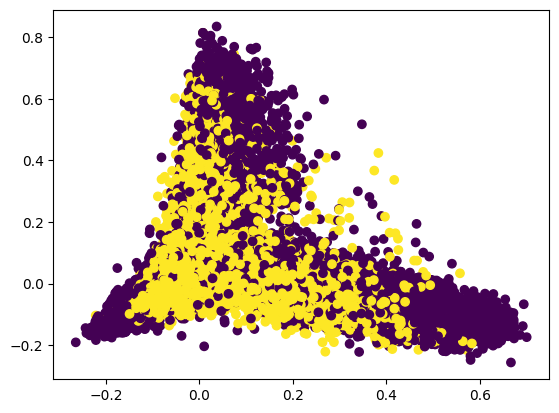

In [ ]:
plt.scatter(pca_reviews[:, 0], pca_reviews[:, 1], c=df['label'].astype('category').cat.codes)

In [ ]:
pca_reviews = pca.fit_transform(scaler.fit_transform(tf_reviews))
pca_reviews

array([[-1.35532736, -0.45605842],
       [-1.19470081, -0.29518073],
       [-0.55784992,  0.06536252],
       ...,
       [-1.62199363,  0.64816485],
       [-2.90287318,  2.04768119],
       [-1.74188187,  0.84245944]])

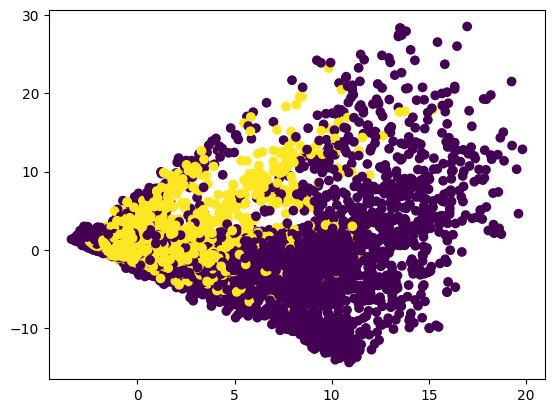

In [ ]:
plt.scatter(pca_reviews[:, 0], pca_reviews[:, 1], c=df['label'].astype('category').cat.codes)

In [ ]:
final_df = pd.concat([tf_reviews, df[['review_len', 'word_count', 'word_to_len_ratio', 'avg_word_len']]], axis=1)
final_df

,10,able,absolutely,absolutely love,act,act good,action,actually,add,addition,...,would recommend anyone,write,year,year old,yet,young,review_len,word_count,word_to_len_ratio,avg_word_len
0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,75,12,6.250000,5.166667
1,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.377647,0.0,0.0,0.0,80,16,5.000000,4.000000
2,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,67,14,4.785714,3.857143
3,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,81,17,4.764706,3.764706
4,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,85,18,4.722222,3.777778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40427,0.000000,0.164208,0.0,0.0,0.0,0.0,0.0,0.089769,0.091075,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,1694,327,5.180428,4.122324
40428,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.090563,...,0.086622,0.0,0.000000,0.0,0.0,0.0,1304,269,4.847584,3.773234
40429,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,1987,333,5.966967,4.924925
40430,0.069288,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,1300,278,4.676259,3.658273


In [ ]:
pca_final = pca.fit_transform(scaler.fit_transform(final_df))
pca_final

array([[-1.4673606 , -1.82432432],
       [-1.38657784, -1.26294209],
       [-0.74281583, -0.78357727],
       ...,
       [-0.77796051,  3.97546515],
       [-2.47962614,  2.70541545],
       [-1.0456138 ,  3.71027867]])

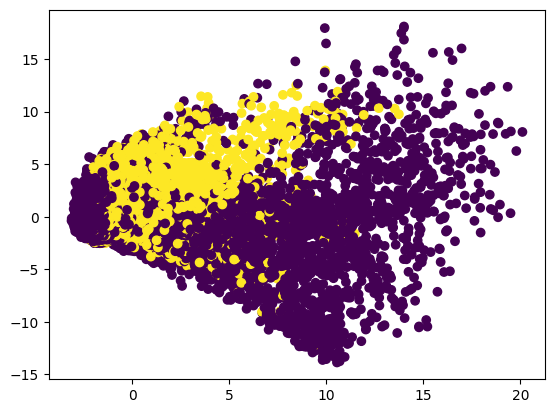

In [ ]:
plt.scatter(pca_final[:, 0], pca_final[:, 1], c=df['label'].astype('category').cat.codes)

In [ ]:
pca_final = pca.fit_transform(final_df)
pca_final

array([[-2.81647594e+02, -3.94589666e+00],
       [-2.76003818e+02, -8.07607512e-01],
       [-2.89150790e+02, -3.92993253e-01],
       ...,
       [ 1.65684463e+03, -3.59369315e+01],
       [ 9.71300308e+02,  3.48769342e+01],
       [ 1.44477161e+03,  2.15375316e+01]])

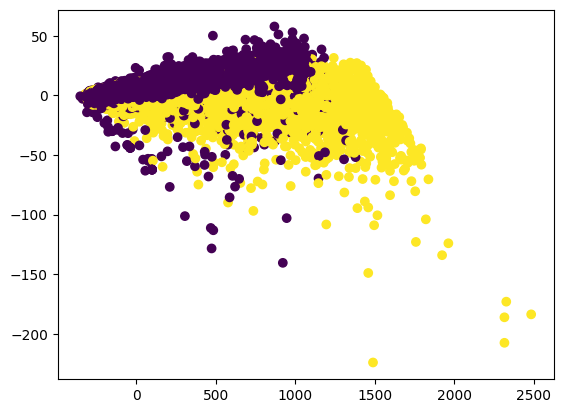

In [ ]:
plt.scatter(pca_final[:, 0], pca_final[:, 1], c=df['label'].astype('category').cat.codes)

save it as csv

In [ ]:
df.to_csv("processed_reviews.csv")